In [28]:
! pip install pyreadstat

In [29]:
import pandas as pd
import pyreadstat

# Replace 'your_file.sav' with the path to your .sav file
file_path_ABSENTEE = 'data/ABSENTEE.SAV'
file_path_BatchId = 'data/BatchId.sav'
file_path_DEATH = 'data/DEATH.SAV'
file_path_Household = 'data/Household.SAV'
file_path_Individual01 = 'data/Individual01.SAV'
file_path_Individual02 = 'data/Individual02.SAV'

Absentee, meta1 = pyreadstat.read_sav(file_path_ABSENTEE)
BatchId, meta2 = pyreadstat.read_sav(file_path_BatchId)
Death, meta3 = pyreadstat.read_sav(file_path_DEATH)
Household, meta4 = pyreadstat.read_sav(file_path_Household)
Individual01, meta5 = pyreadstat.read_sav(file_path_Individual01)
Individual02, meta6 = pyreadstat.read_sav(file_path_Individual02)

"""df1.to_csv("ABSENTEE.csv", index=False)
   df2.to_csv("BatchId.csv", index=False)
   df3.to_csv("DEATH.csv", index=False)
   df4.to_csv("Household.csv", index=False)
   df5.to_csv("Individual01.csv", index=False)
   df6.to_csv("Individual02.csv", index=False)"""

'df1.to_csv("ABSENTEE.csv", index=False)\n   df2.to_csv("BatchId.csv", index=False)\n   df3.to_csv("DEATH.csv", index=False)\n   df4.to_csv("Household.csv", index=False)\n   df5.to_csv("Individual01.csv", index=False)\n   df6.to_csv("Individual02.csv", index=False)'

# 1. ABSENTEE DATA 

In [30]:
print("Absentee Data")
Absentee.head()
Absentee.shape

Absentee Data


(282429, 13)

In [31]:
# Total number of rows (entries)
print("Total entries (rows) in absentee data:", len(Absentee))
Absentee.describe()

Total entries (rows) in absentee data: 282429


,DIST,VDCMUN,WARD,EA,HNO,HHNO,H14IDC,H14SEX,H14AGE,H14EDU,H14DRTN,H14RSN,H14CNTRY
count,282429.000000,282429.000000,282429.000000,282429.000000,282429.000000,282429.000000,282429.000000,282429.000000,282429.000000,276880.000000,282429.000000,282429.000000,282429.000000
mean,36.016698,30.971809,5.845646,1.556607,114.063365,145.745812,1.472646,1.123603,26.412351,26.148252,6.424570,2.865665,4.116298
std,20.873114,21.786073,4.137544,5.545786,152.614490,211.860428,1.028858,0.330631,13.248075,35.678896,15.479773,1.775505,10.107282
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,17.000000,13.000000,3.000000,0.000000,28.000000,34.000000,1.000000,1.000000,20.000000,6.000000,1.000000,2.000000,1.000000
50%,38.000000,28.000000,5.000000,0.000000,64.000000,78.000000,1.000000,1.000000,24.000000,10.000000,2.000000,2.000000,3.000000
75%,50.000000,43.000000,8.000000,1.000000,133.000000,171.000000,2.000000,1.000000,30.000000,12.000000,5.000000,3.000000,4.000000
max,75.000000,115.000000,35.000000,84.000000,5741.000000,8856.000000,25.000000,9.000000,99.000000,99.000000,99.000000,9.000000,99.000000


In [32]:
print("Columns:\n", Absentee.columns.tolist())  # Lists all column names
print("Number of columns:",len(Absentee.columns))  # Counts the number of columns


Columns:
 ['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H14IDC', 'H14SEX', 'H14AGE', 'H14EDU', 'H14DRTN', 'H14RSN', 'H14CNTRY']
Number of columns: 13


# Data Cleaning

### # Handling missing values and duplicates


In [33]:
# Handling missing values and duplicates
print("Missing Values Per Column:\n")
print(Absentee.isnull().sum())
print("\nNumber of Duplicate Rows:", Absentee.duplicated().sum())

Missing Values Per Column:

DIST           0
VDCMUN         0
WARD           0
EA             0
HNO            0
HHNO           0
H14IDC         0
H14SEX         0
H14AGE         0
H14EDU      5549
H14DRTN        0
H14RSN         0
H14CNTRY       0
dtype: int64

Number of Duplicate Rows: 0


In [34]:
# let's see how big that is proportionally to decide what to do:
total_rows = len(Absentee)

missing_education = Absentee['H14EDU'].isnull().sum()

missing_ratio_education = missing_education / total_rows

print(f"Missing ratio in Education column: {missing_ratio_education:.2%}")


Missing ratio in Education column: 1.96%


In [35]:
#The value for education column is small so we can drop those rows(5-10% missing)
Absentee_clean = Absentee.dropna(subset=['H14EDU'])

### # Handling Inconsistent Data


In [36]:
# Handling In consistent Data( Age and duration < 0)
print(Absentee[Absentee['H14AGE'] < 0])
print(Absentee[Absentee['H14DRTN'] < 0])

Empty DataFrame
Columns: [DIST, VDCMUN, WARD, EA, HNO, HHNO, H14IDC, H14SEX, H14AGE, H14EDU, H14DRTN, H14RSN, H14CNTRY]
Index: []
Empty DataFrame
Columns: [DIST, VDCMUN, WARD, EA, HNO, HHNO, H14IDC, H14SEX, H14AGE, H14EDU, H14DRTN, H14RSN, H14CNTRY]
Index: []


In [37]:
# For '14. Age of absentees'
min_age = Absentee['H14AGE'].min()
max_age = Absentee['H14AGE'].max()
print(f"Age - Min: {min_age}, Max: {max_age}")

# For '14. Duration of absent (year)' excluding missing (-1)
min_duration = Absentee['H14DRTN'].min()
max_duration = Absentee['H14DRTN'].max()
print(f"Duration - Min: {min_duration}, Max: {max_duration}")



Age - Min: 0.0, Max: 99.0
Duration - Min: 0.0, Max: 99.0


In [38]:
# Replace 99.0 with NaN in Age column beacause 99.0 = 'Not Stated'in metadata
Absentee['H14AGE'] = Absentee['H14AGE'].replace(99.0, pd.NA)

# Replace 99.0 with NaN in Duration of absent column
Absentee['H14DRTN'] = Absentee['H14DRTN'].replace(99.0, pd.NA)


In [39]:
# For '14. Age of absentees'
min_age = Absentee['H14AGE'].min()
max_age = Absentee['H14AGE'].max()
print(f"Age - Min: {min_age}, Max: {max_age}")

# For '14. Duration of absent (year)'
min_duration = Absentee['H14DRTN'].min()
max_duration = Absentee['H14DRTN'].max()
print(f"Duration - Min: {min_duration}, Max: {max_duration}")



Age - Min: 0.0, Max: 75.0
Duration - Min: 0.0, Max: 60.0


In [40]:
age_cleaned = Absentee[Absentee['H14AGE'].notna()].copy()
duration_cleaned = Absentee[Absentee['H14DRTN'].notna()].copy()

### Extracting and Applying Metadata (Labels and Descriptions)

In [41]:
print(meta1.column_names)
print(meta1.column_labels)

['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H14IDC', 'H14SEX', 'H14AGE', 'H14EDU', 'H14DRTN', 'H14RSN', 'H14CNTRY']
['District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 'House no.', 'Household no.', '14. ID Code of absentees', '14. Sex of absentees', '14. Age of absentees', '14. Education of absentees', '14. Duration of absent (year)', '14. Reason of absent', '14. Destination']


In [42]:
# Get value labels for categorical variables
print(meta1.value_labels)

{'labels0': {1.0: 'Taplejung', 2.0: 'Panchthar', 3.0: 'Ilam', 4.0: 'Jhapa', 5.0: 'Morang', 6.0: 'Sunsari', 7.0: 'Dhankuta', 8.0: 'Terhathum', 9.0: 'Sankhuwasabha', 10.0: 'Bhojpur', 11.0: 'Solukhumbu', 12.0: 'Okhaldhunga', 13.0: 'Khotang', 14.0: 'Udayapur', 15.0: 'Saptari', 16.0: 'Siraha', 17.0: 'Dhanusa', 18.0: 'Mahottari', 19.0: 'Sarlahi', 20.0: 'Sindhuli', 21.0: 'Ramechhap', 22.0: 'Dolakha', 23.0: 'Sindhupalchok', 24.0: 'Kavrepalanchok', 25.0: 'Lalitpur', 26.0: 'Bhaktapur', 27.0: 'Kathmandu', 28.0: 'Nuwakot', 29.0: 'Rasuwa', 30.0: 'Dhading', 31.0: 'Makwanpur', 32.0: 'Rautahat', 33.0: 'Bara', 34.0: 'Parsa', 35.0: 'Chitawan', 36.0: 'Gorkha', 37.0: 'Lamjung', 38.0: 'Tanahu', 39.0: 'Syangja', 40.0: 'Kaski', 41.0: 'Manang', 42.0: 'Mustang', 43.0: 'Myagdi', 44.0: 'Parbat', 45.0: 'Baglung', 46.0: 'Gulmi', 47.0: 'Palpa', 48.0: 'Nawalparasi', 49.0: 'Rupandehi', 50.0: 'Kapilbastu', 51.0: 'Arghakhanchi', 52.0: 'Pyuthan', 53.0: 'Rolpa', 54.0: 'Rukum', 55.0: 'Salyan', 56.0: 'Dang', 57.0: 'Banke',

In [43]:
for label_key, mapping_dict in meta1.value_labels.items():
    key_types = set(type(k) for k in mapping_dict.keys())
    value_types = set(type(v) for v in mapping_dict.values())
    print(f"{label_key} key types: {key_types}")
    print(f"{label_key} value types: {value_types}")

labels0 key types: {<class 'float'>}
labels0 value types: {<class 'str'>}
labels1 key types: {<class 'float'>}
labels1 value types: {<class 'str'>}
labels2 key types: {<class 'float'>}
labels2 value types: {<class 'str'>}
labels3 key types: {<class 'float'>}
labels3 value types: {<class 'str'>}
labels4 key types: {<class 'float'>}
labels4 value types: {<class 'str'>}
labels5 key types: {<class 'float'>}
labels5 value types: {<class 'str'>}
labels6 key types: {<class 'float'>}
labels6 value types: {<class 'str'>}


### Rename columns in the DataFrame using metadata


In [44]:
col_names = ['DIST', 'VDCMUN', 'WARD', 'EA', 'HNO', 'HHNO', 'H14IDC', 'H14SEX', 'H14AGE', 'H14EDU', 'H14DRTN', 'H14RSN', 'H14CNTRY']
col_labels = ['District', 'V.D.C./Municipality', 'Ward no.', 'Enumeration area', 'House no.', 'Household no.', '14. ID Code of absentees', '14. Sex of absentees', '14. Age of absentees', '14. Education of absentees', '14. Duration of absent (year)', '14. Reason of absent', '14. Destination']

# Create a dictionary mapping column names to labels
rename_dict = dict(zip(col_names, col_labels))

# Rename columns in the DataFrame
Absentee.rename(columns=rename_dict, inplace=True)


In [45]:
Absentee.head()

,District,V.D.C./Municipality,Ward no.,Enumeration area,House no.,Household no.,14. ID Code of absentees,14. Sex of absentees,14. Age of absentees,14. Education of absentees,14. Duration of absent (year),14. Reason of absent,14. Destination
0,1.0,1.0,1.0,0.0,29.0,29.0,1.0,1.0,28.0,9.0,0.0,2.0,4.0
1,1.0,1.0,1.0,0.0,53.0,53.0,1.0,1.0,39.0,11.0,21.0,2.0,4.0
2,1.0,1.0,2.0,0.0,17.0,20.0,1.0,1.0,43.0,3.0,0.0,2.0,3.0
3,1.0,1.0,2.0,0.0,25.0,28.0,1.0,1.0,33.0,10.0,2.0,2.0,4.0
4,1.0,1.0,2.0,0.0,46.0,52.0,1.0,1.0,18.0,6.0,2.0,2.0,3.0


In [46]:
print(Absentee.dtypes)


District                         float64
V.D.C./Municipality              float64
Ward no.                         float64
Enumeration area                 float64
House no.                        float64
Household no.                    float64
14. ID Code of absentees         float64
14. Sex of absentees             float64
14. Age of absentees              object
14. Education of absentees       float64
14. Duration of absent (year)     object
14. Reason of absent             float64
14. Destination                  float64
dtype: object


In [47]:
print(Absentee['14. Duration of absent (year)'].unique())
print(Absentee['14. Age of absentees'].unique())


[0.0 21.0 2.0 1.0 10.0 9.0 <NA> 5.0 11.0 4.0 3.0 8.0 22.0 7.0 6.0 13.0
 15.0 16.0 14.0 18.0 20.0 17.0 12.0 19.0 57.0 44.0 52.0 47.0 25.0 30.0
 48.0 27.0 60.0 24.0 29.0 35.0 40.0 50.0 33.0 34.0 46.0 38.0 32.0 28.0
 45.0 23.0 26.0 54.0 31.0 55.0 36.0 43.0 41.0 39.0 42.0 51.0 37.0 53.0
 58.0 56.0 49.0 59.0]
[28.0 39.0 43.0 33.0 18.0 19.0 40.0 14.0 30.0 35.0 24.0 29.0 20.0 42.0
 27.0 26.0 21.0 34.0 22.0 23.0 31.0 51.0 49.0 17.0 32.0 16.0 11.0 41.0
 25.0 6.0 4.0 54.0 44.0 37.0 38.0 <NA> 63.0 8.0 10.0 36.0 2.0 9.0 45.0
 50.0 47.0 46.0 1.0 15.0 13.0 52.0 65.0 12.0 0.0 58.0 5.0 60.0 59.0 3.0
 48.0 53.0 55.0 7.0 56.0 57.0 61.0 75.0 64.0 70.0 66.0 62.0 68.0 73.0 71.0
 69.0 67.0 72.0 74.0]


### # Mapping dictionary: key = label key in metadata, value = column name in DataFrame


In [48]:
# Mapping dictionary: key = label key in metadata, value = column name in DataFrame
label_to_column = {
    'labels0': 'District',
    'labels1': '14. Sex of absentees',
    'labels3': '14. Education of absentees',
    'labels5': '14. Reason of absent',
    'labels6': '14. Destination'
}

for label_key, col_name in label_to_column.items():
    if label_key in meta1.value_labels:
        Absentee[col_name] = Absentee[col_name].map(meta1.value_labels[label_key])


In [49]:
Absentee.head()

,District,V.D.C./Municipality,Ward no.,Enumeration area,House no.,Household no.,14. ID Code of absentees,14. Sex of absentees,14. Age of absentees,14. Education of absentees,14. Duration of absent (year),14. Reason of absent,14. Destination
0,Taplejung,1.0,1.0,0.0,29.0,29.0,1.0,Male,28.0,Class 9,0.0,Pvt. service/job,Middle east country
1,Taplejung,1.0,1.0,0.0,53.0,53.0,1.0,Male,39.0,SLC or equivalent,21.0,Pvt. service/job,Middle east country
2,Taplejung,1.0,2.0,0.0,17.0,20.0,1.0,Male,43.0,Class 3,0.0,Pvt. service/job,ASEAN country
3,Taplejung,1.0,2.0,0.0,25.0,28.0,1.0,Male,33.0,Class 10,2.0,Pvt. service/job,Middle east country
4,Taplejung,1.0,2.0,0.0,46.0,52.0,1.0,Male,18.0,Class 6,2.0,Pvt. service/job,ASEAN country


# Descriptive Analysis

# Data Exploration Tasks

### Distribution Analysis of Absentee dataset.

C:\Users\sagun\AppData\Local\Temp\ipykernel_5328\3030636012.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_counts.index, y=district_counts.values, palette="viridis")


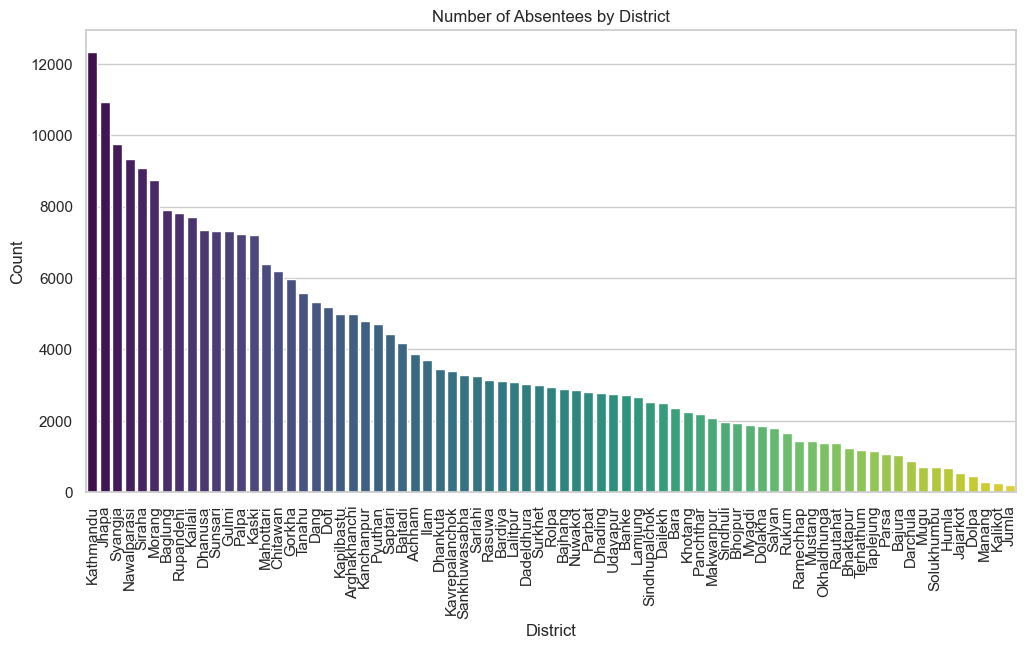

Absentees by District:
District
Kathmandu      12328
Jhapa          10934
Syangja         9750
Nawalparasi     9325
Siraha          9087
               ...  
Jajarkot         537
Dolpa            447
Manang           279
Kalikot          244
Jumla            203
Name: count, Length: 75, dtype: int64




C:\Users\sagun\AppData\Local\Temp\ipykernel_5328\3030636012.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values, palette="pastel")


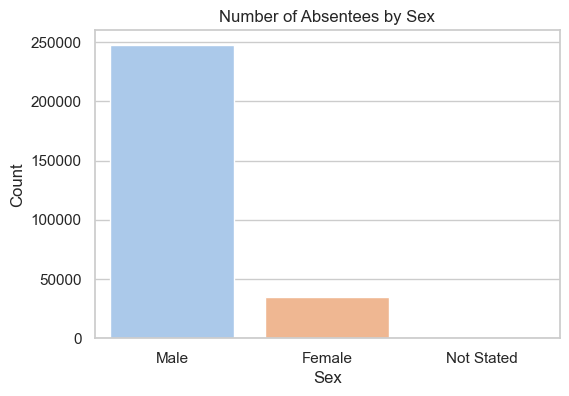

Absentees by Sex:
14. Sex of absentees
Male          247555
Female         34869
Not Stated         5
Name: count, dtype: int64




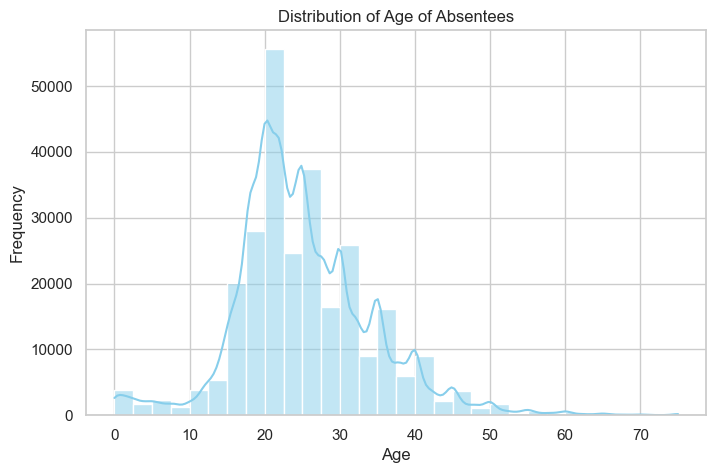

Absentees by Age:
14. Age of absentees
20.0    21313
22.0    19267
25.0    18160
18.0    16384
21.0    15082
        ...  
69.0       15
72.0       15
71.0        9
73.0        8
74.0        8
Name: count, Length: 76, dtype: int64




C:\Users\sagun\AppData\Local\Temp\ipykernel_5328\3030636012.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="muted")


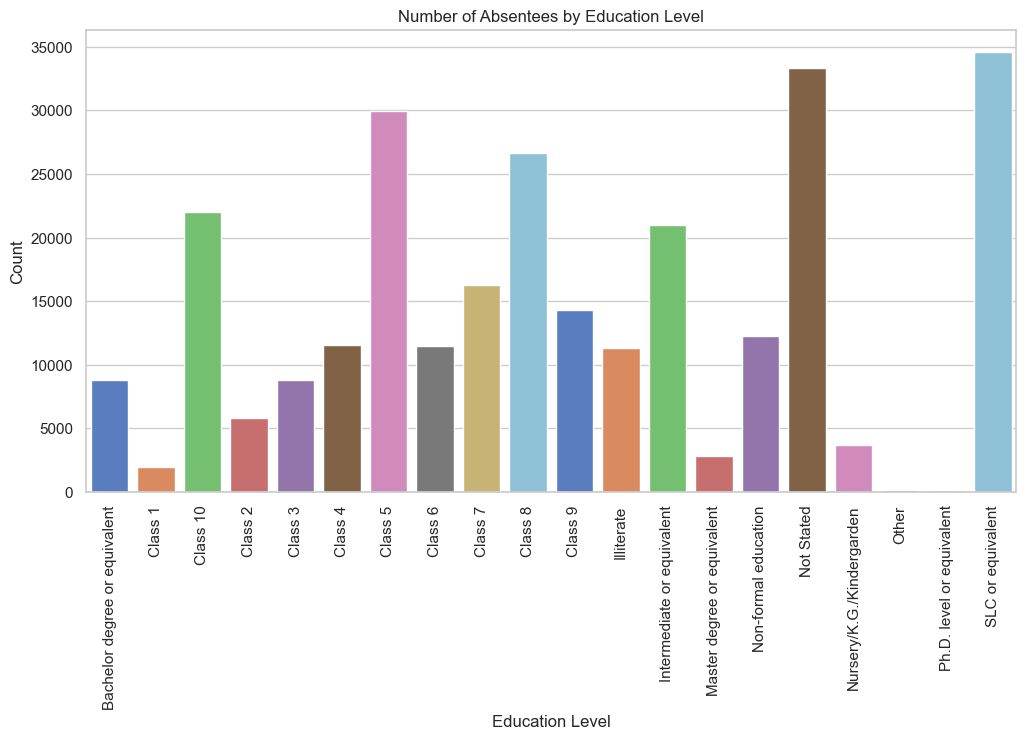

Absentees by Education Level:
14. Education of absentees
SLC or equivalent                34590
Not Stated                       33304
Class 5                          29972
Class 8                          26639
Class 10                         22035
Intermediate or equivalent       21006
Class 7                          16265
Class 9                          14295
Non-formal education             12267
Class 4                          11535
Class 6                          11482
Illiterate                       11355
Bachelor degree or equivalent     8785
Class 3                           8781
Class 2                           5787
Nursery/K.G./Kindergarden         3675
Master degree or equivalent       2845
Class 1                           1947
Ph.D. level or equivalent          184
Other                              131
Name: count, dtype: int64




C:\Users\sagun\AppData\Local\Temp\ipykernel_5328\3030636012.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.index, y=reason_counts.values, palette="Set2")


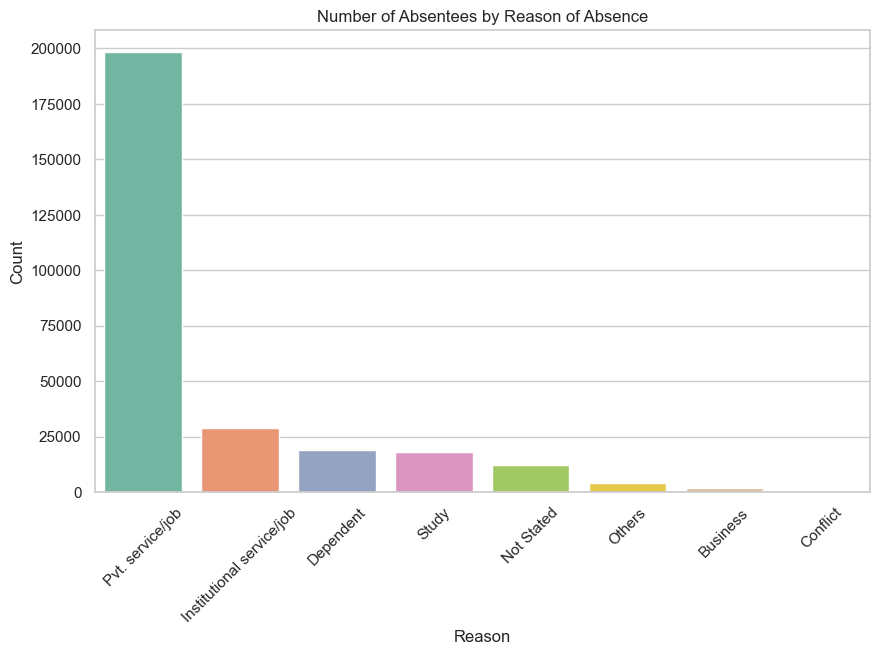

Absentees by Reason of Absence:
14. Reason of absent
Pvt. service/job             198272
Institutional service/job     28737
Dependent                     18773
Study                         18171
Not Stated                    12130
Others                         3997
Business                       1906
Conflict                        443
Name: count, dtype: int64




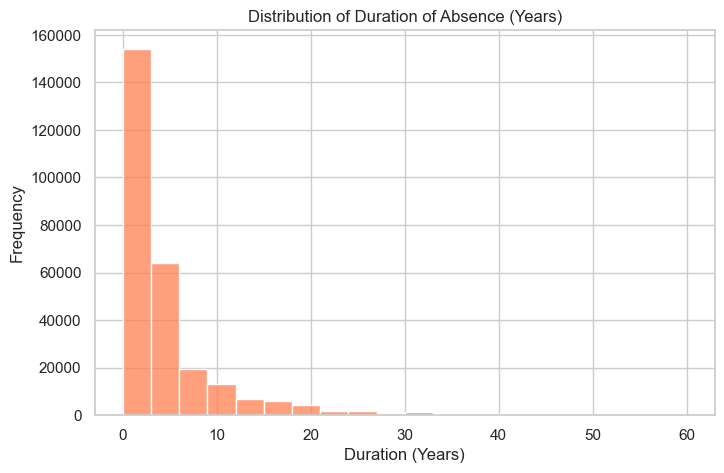

Absentees by Duration of Absence:
14. Duration of absent (year)
1.0     64347
2.0     49137
0.0     40739
3.0     32199
4.0     16513
        ...  
49.0       17
51.0       16
53.0       11
57.0        7
59.0        1
Name: count, Length: 61, dtype: int64




In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# 1. Distribution of absentees by District (bar plot)
plt.figure(figsize=(12,6))
district_counts = Absentee['District'].value_counts().sort_values(ascending=False)
sns.barplot(x=district_counts.index, y=district_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Number of Absentees by District")
plt.ylabel("Count")
plt.xlabel("District")
plt.show()

# 1. Counts by District
print("Absentees by District:")
print(Absentee['District'].value_counts())
print("\n")

# 2. Distribution by Sex (bar plot)
plt.figure(figsize=(6,4))
sex_counts = Absentee['14. Sex of absentees'].value_counts()
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette="pastel")
plt.title("Number of Absentees by Sex")
plt.ylabel("Count")
plt.xlabel("Sex")
plt.show()

# 2. Counts by Sex
print("Absentees by Sex:")
print(Absentee['14. Sex of absentees'].value_counts())
print("\n")

# 3. Distribution by Age (histogram)
plt.figure(figsize=(8,5))
sns.histplot(Absentee['14. Age of absentees'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Distribution of Age of Absentees")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
print("Absentees by Age:")
print(Absentee['14. Age of absentees'].value_counts())
print("\n")


# 4. Distribution by Education Level (bar plot)
plt.figure(figsize=(12,6))
edu_counts = Absentee['14. Education of absentees'].value_counts().sort_index()
sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="muted")
plt.xticks(rotation=90)
plt.title("Number of Absentees by Education Level")
plt.ylabel("Count")
plt.xlabel("Education Level")
plt.show()

# 4. Counts by Education Level
print("Absentees by Education Level:")
print(Absentee['14. Education of absentees'].value_counts())
print("\n")

# 5. Distribution by Reason of Absence (bar plot)
plt.figure(figsize=(10,6))
reason_counts = Absentee['14. Reason of absent'].value_counts().sort_values(ascending=False)
sns.barplot(x=reason_counts.index, y=reason_counts.values, palette="Set2")
plt.xticks(rotation=45)
plt.title("Number of Absentees by Reason of Absence")
plt.ylabel("Count")
plt.xlabel("Reason")
plt.show()

# 5. Counts by Reason of Absence
print("Absentees by Reason of Absence:")
print(Absentee['14. Reason of absent'].value_counts())
print("\n")

# 6. Distribution of Duration of Absence (histogram)
plt.figure(figsize=(8,5))
sns.histplot(Absentee['14. Duration of absent (year)'].dropna(), bins=20, kde=False, color='coral')
plt.title("Distribution of Duration of Absence (Years)")
plt.xlabel("Duration (Years)")
plt.ylabel("Frequency")
plt.show()

# 6. Counts by Reason of Absence
print("Absentees by Duration of Absence:")
print(Absentee['14. Duration of absent (year)'].value_counts())
print("\n")


### Cross-tabulation / Group Analysis:

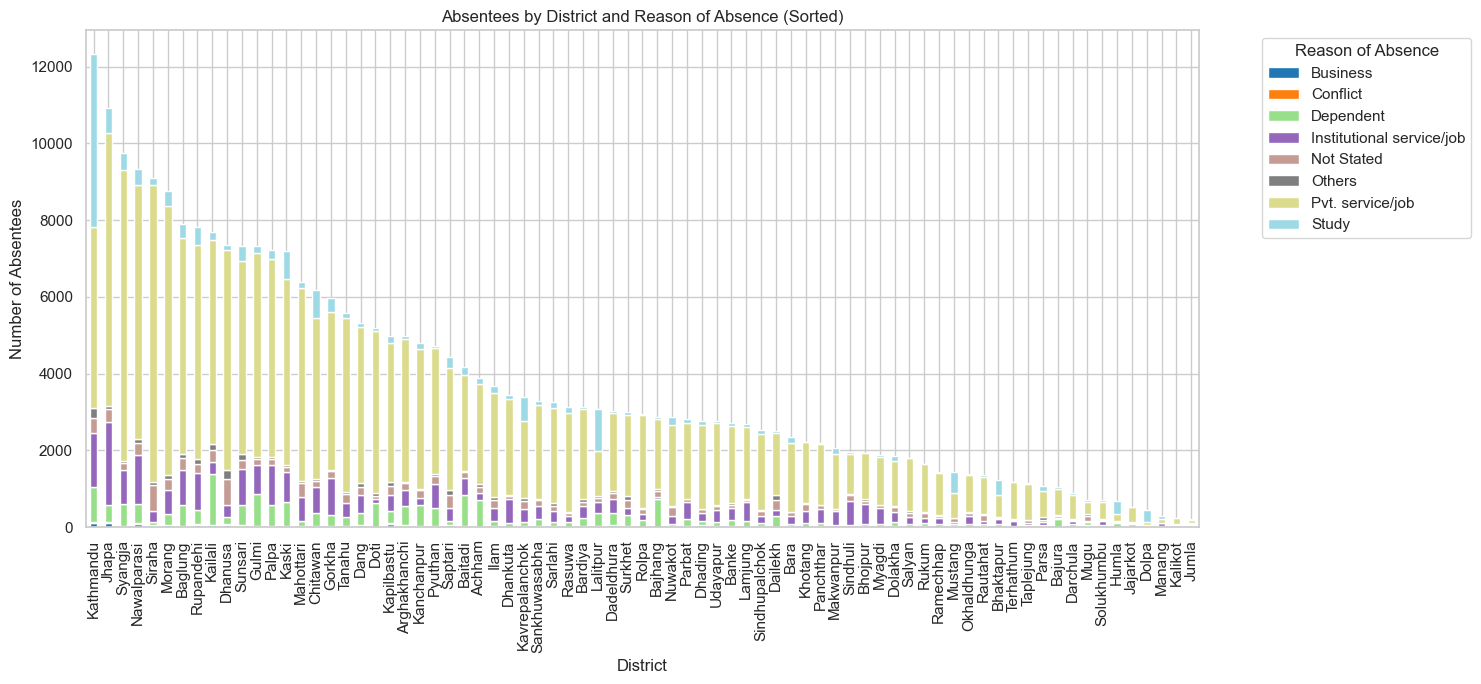

In [51]:
# Cross-tabulation
district_reason = pd.crosstab(Absentee['District'], Absentee['14. Reason of absent'])

# Sort by total absentees per district (row sum)
district_reason_sorted = district_reason.loc[district_reason.sum(axis=1).sort_values(ascending=False).index]

# Plot
district_reason_sorted.plot(kind='bar', stacked=True, figsize=(15,7), colormap='tab20')
plt.title('Absentees by District and Reason of Absence (Sorted)')
plt.xlabel('District')
plt.ylabel('Number of Absentees')
plt.legend(title='Reason of Absence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


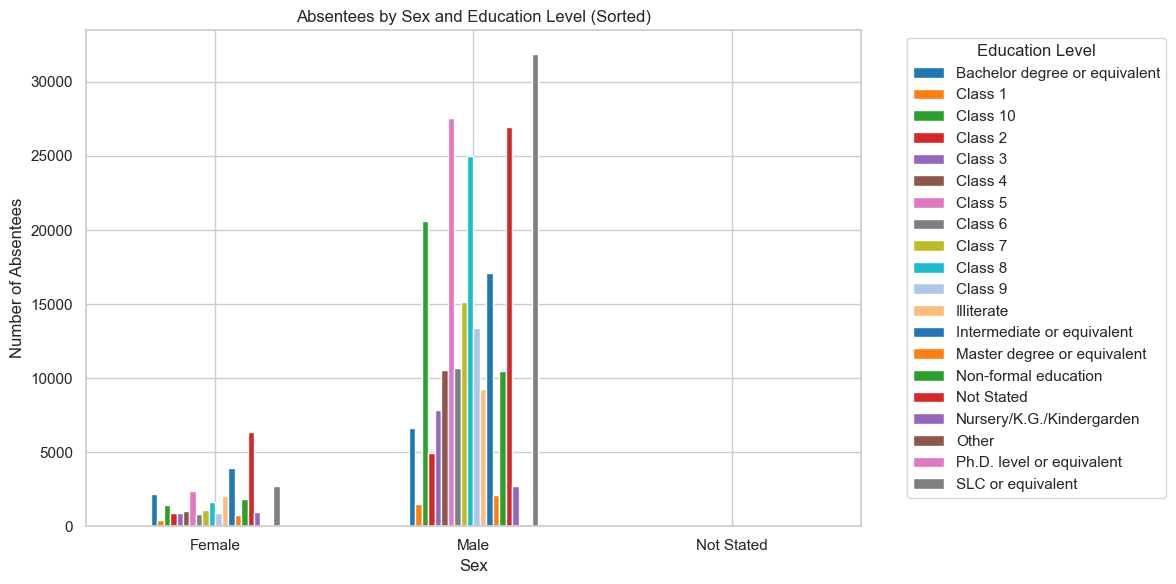

14. Education of absentees  Bachelor degree or equivalent  Class 1  Class 10  \
14. Sex of absentees                                                           
Female                                               2182      451      1434   
Male                                                 6603     1496     20601   
Not Stated                                              0        0         0   

14. Education of absentees  Class 2  Class 3  Class 4  Class 5  Class 6  \
14. Sex of absentees                                                      
Female                          870      916     1005     2374      823   
Male                           4917     7865    10530    27598    10659   
Not Stated                        0        0        0        0        0   

14. Education of absentees  Class 7  Class 8  Class 9  Illiterate  \
14. Sex of absentees                                                
Female                         1110     1642      928        2065   
Male            

In [58]:
# Sort by total across all education levels (row-wise)
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']

sex_education = pd.crosstab(Absentee['14. Sex of absentees'], Absentee['14. Education of absentees'])


# Plot
sex_education.plot(kind='bar', figsize=(12,6), color=custom_colors)
plt.title('Absentees by Sex and Education Level (Sorted)')
plt.xlabel('Sex')
plt.ylabel('Number of Absentees')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: print sorted table
print(sex_education)




C:\Users\sagun\AppData\Local\Temp\ipykernel_4780\3009511484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_duration_district.index, y=avg_duration_district.values, palette='coolwarm')


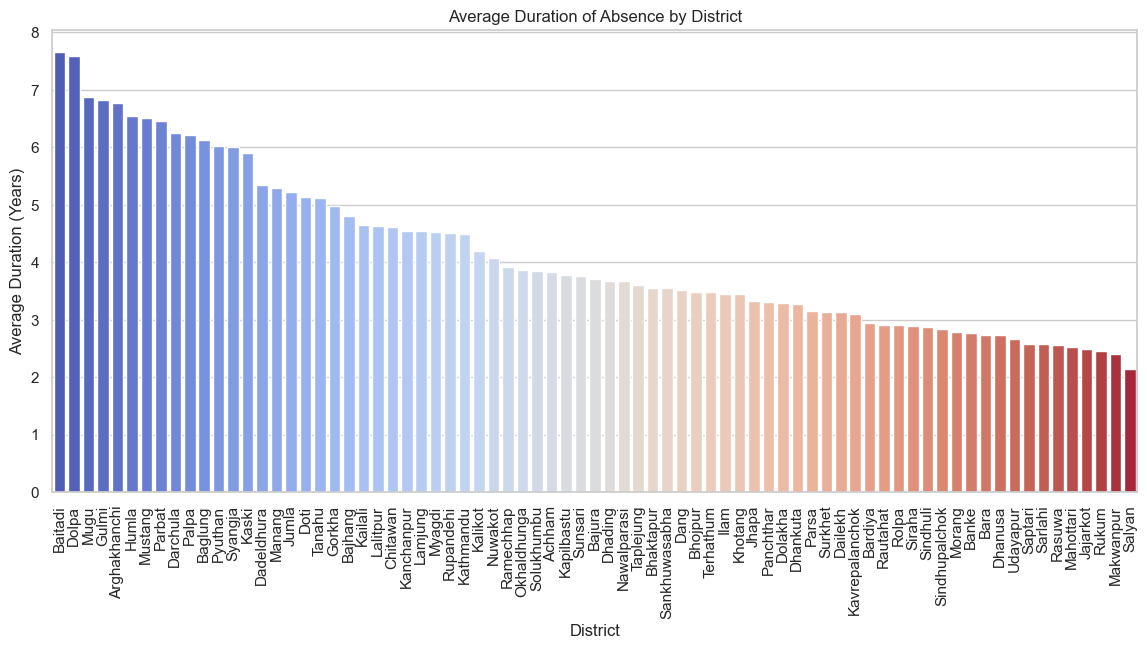

In [ ]:
# Average Duration by District
avg_duration_district = Absentee.groupby('District')['14. Duration of absent (year)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=avg_duration_district.index, y=avg_duration_district.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Average Duration of Absence by District')
plt.ylabel('Average Duration (Years)')
plt.xlabel('District')
plt.show()

C:\Users\sagun\AppData\Local\Temp\ipykernel_4780\986352671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_duration_reason.index, y=avg_duration_reason.values, palette='magma')


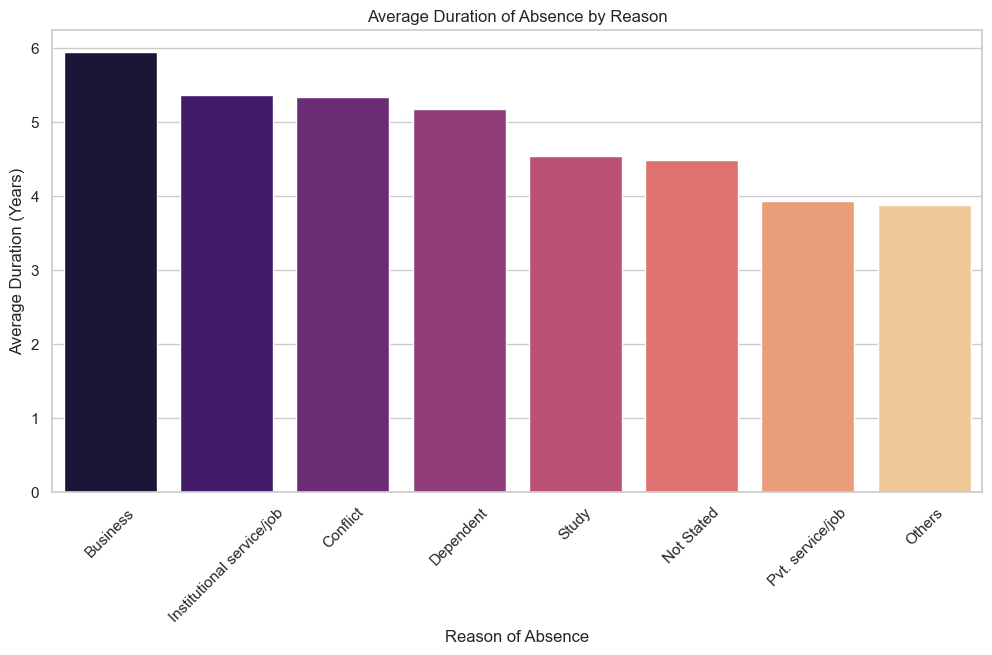

In [ ]:
# Average Duration by Reason
avg_duration_reason = Absentee.groupby('14. Reason of absent')['14. Duration of absent (year)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_duration_reason.index, y=avg_duration_reason.values, palette='magma')
plt.xticks(rotation=45)
plt.title('Average Duration of Absence by Reason')
plt.ylabel('Average Duration (Years)')
plt.xlabel('Reason of Absence')
plt.show()

# Diagnostic Analysis

# Trend Analysis

### Absentee Counts Across Different Age Groups

C:\Users\sagun\AppData\Local\Temp\ipykernel_4780\2412301757.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=age_cleaned, x='AgeGroup', palette='crest', order=age_labels)


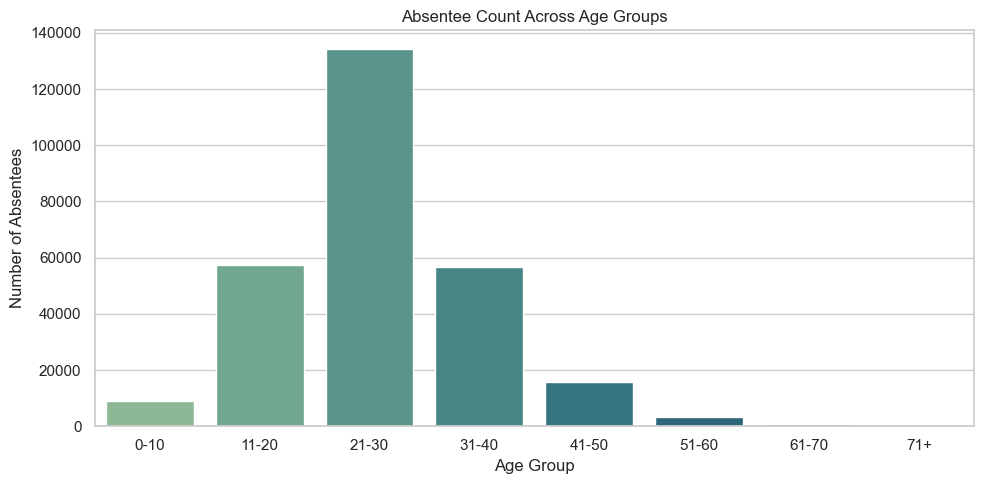

In [ ]:
# Drop rows with missing age before binning
age_cleaned = Absentee[Absentee['14. Age of absentees'].notna()].copy()

# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']

# Apply binning safely
age_cleaned['AgeGroup'] = pd.cut(age_cleaned['14. Age of absentees'], bins=age_bins, labels=age_labels, right=False)

# Now plot the counts
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=age_cleaned, x='AgeGroup', palette='crest', order=age_labels)
plt.title('Absentee Count Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Absentees')
plt.tight_layout()
plt.show()


14. Destination
Middle east country              105866
India                            104633
ASEAN country                     36843
European union country             8714
North american country             7677
Other asian country                7030
Pacific Ocean Region country       4078
Not Stated                         3037
SAARC country                      1909
African country                     825
Others                              796
Other european country              622
South arican/caribean country       399
Name: count, dtype: int64


C:\Users\sagun\AppData\Local\Temp\ipykernel_4780\3290016803.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=destination_counts.index, y=destination_counts.values, palette='viridis')


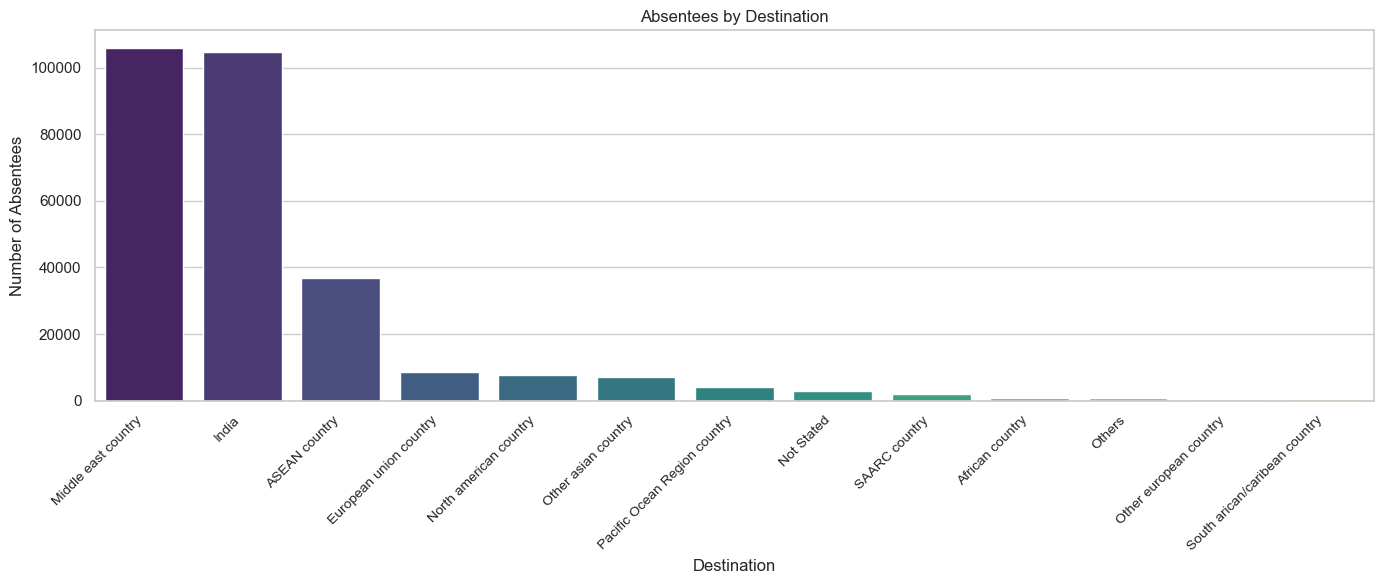

In [ ]:
# Count of absentees by destination
destination_counts = Absentee['14. Destination'].value_counts()

print(destination_counts)  # Print counts

plt.figure(figsize=(14,6))  # wider figure
sns.barplot(x=destination_counts.index, y=destination_counts.values, palette='viridis')
plt.title('Absentees by Destination')
plt.xlabel('Destination')
plt.ylabel('Number of Absentees')
plt.xticks(rotation=45, ha='right', fontsize=10)  # rotate 45° and align right
plt.tight_layout()
plt.show()


14. Reason of absent           Business  Conflict  Dependent  \
14. Destination                                                
ASEAN country                       372        35       1439   
African country                       7         3         62   
European union country               83        22       1614   
India                              1177       195      12649   
Middle east country                  12       124        479   
North american country               58        26       1050   
Not Stated                           21         6        221   
Other asian country                 124        10        745   
Other european country               11         2         46   
Others                                5         4         67   
Pacific Ocean Region country         23        13        313   
SAARC country                        10         3         65   
South arican/caribean country         3         0         23   

14. Reason of absent           Institut

<Figure size 1400x700 with 0 Axes>

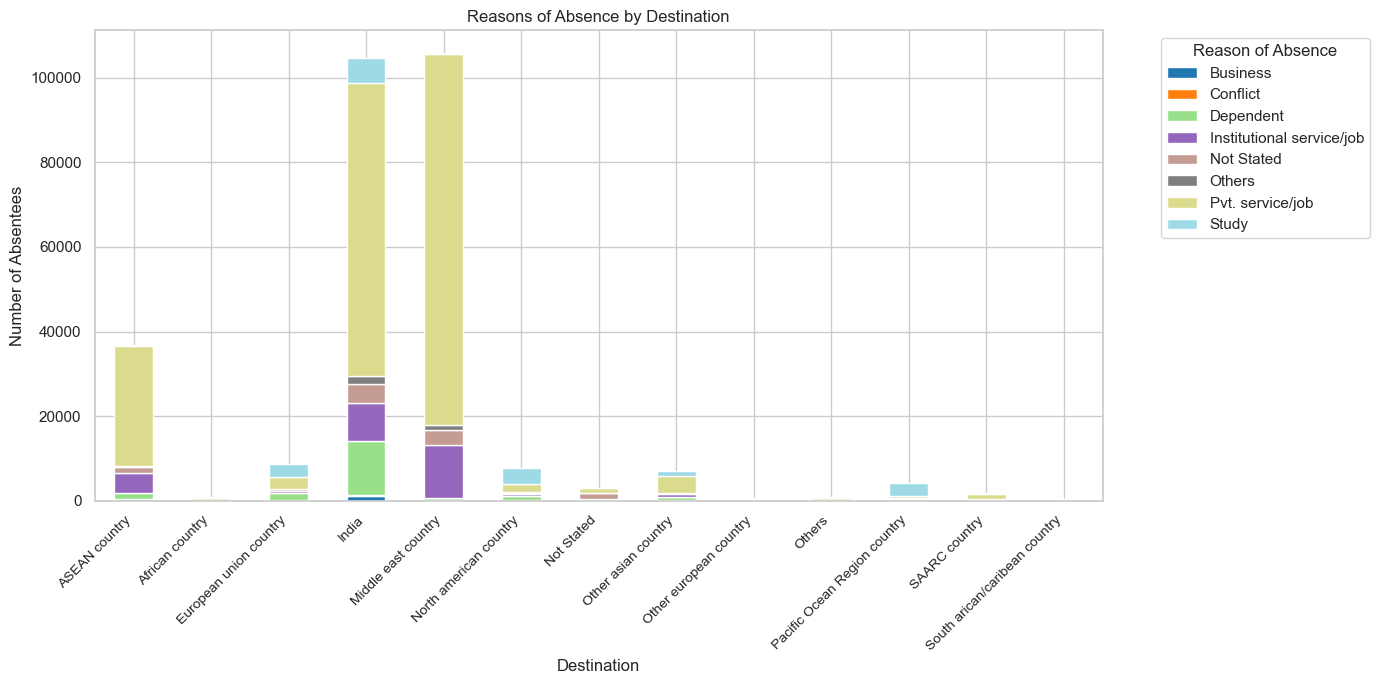

In [ ]:
# Cross-tabulation of Reason vs Destination
reason_destination = pd.crosstab(Absentee['14. Destination'], Absentee['14. Reason of absent'])

print(reason_destination)  # Print counts

plt.figure(figsize=(14,7))  # make wider figure for more space
reason_destination.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14,7))

plt.title('Reasons of Absence by Destination')
plt.xlabel('Destination')
plt.ylabel('Number of Absentees')

plt.xticks(rotation=45, ha='right', fontsize=10)  # rotate and align right, smaller font
plt.legend(title='Reason of Absence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



# Predictive Analysis

# Data Mining Task

###  Classification model to predict the Reason of Absence based on Age, Sex, Education, and District.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns and drop rows with missing values
clf_data = Absentee[['14. Age of absentees', '14. Sex of absentees', '14. Education of absentees', 'District', '14. Reason of absent']].dropna().copy()

# Encode categorical variables
le_sex = LabelEncoder()
clf_data['Sex_Code'] = le_sex.fit_transform(clf_data['14. Sex of absentees'])

le_edu = LabelEncoder()
clf_data['Edu_Code'] = le_edu.fit_transform(clf_data['14. Education of absentees'])

le_district = LabelEncoder()
clf_data['District_Code'] = le_district.fit_transform(clf_data['District'])

le_reason = LabelEncoder()
clf_data['Reason_Code'] = le_reason.fit_transform(clf_data['14. Reason of absent'])

# Features and target variable
X = clf_data[['14. Age of absentees', 'Sex_Code', 'Edu_Code', 'District_Code']]
y = clf_data['Reason_Code']

# Split data into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  )
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  )
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be remove

In [ ]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype

RandomForestClassifier(random_state=42)

c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
c:\Users\sagun\anaconda3\Lib\site-packages\pandas\core\algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype

Classification Report:

                           precision    recall  f1-score   support

                 Business       0.02      0.00      0.01       563
                 Conflict       0.03      0.01      0.01       127
                Dependent       0.48      0.37      0.42      3952
Institutional service/job       0.18      0.04      0.07      8511
               Not Stated       0.09      0.02      0.03      3045
                   Others       0.08      0.02      0.03      1111
         Pvt. service/job       0.78      0.93      0.85     58903
                    Study       0.57      0.57      0.57      5387

                 accuracy                           0.73     81599
                macro avg       0.28      0.25      0.25     81599
             weighted avg       0.65      0.73      0.68     81599



c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  )
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  )
c:\Users\sagun\anaconda3\Lib\site-packages\sklearn\utils\validation.py:605: DeprecationWarning: is_sparse is deprecated and will be remove

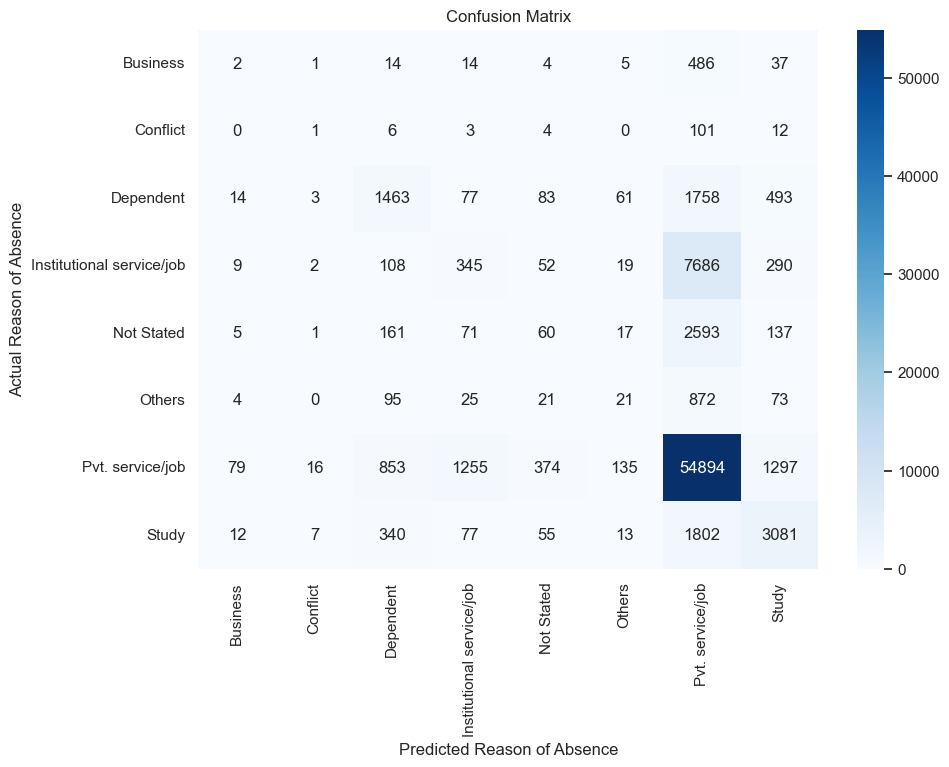

In [ ]:
y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_reason.classes_))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_reason.classes_, yticklabels=le_reason.classes_, cmap='Blues')
plt.xlabel('Predicted Reason of Absence')
plt.ylabel('Actual Reason of Absence')
plt.title('Confusion Matrix')
plt.show()


###  Association Rule Mining on absentee data to find interesting patterns between features like Education, Reason of Absence, District, and Sex.

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Select relevant categorical columns
assoc_data = Absentee[['14. Education of absentees', '14. Reason of absent', 'District', '14. Sex of absentees']].dropna()

# One-hot encode the categorical variables
df_onehot = pd.get_dummies(assoc_data)

print("One-hot encoded data sample:")
df_onehot.head()


One-hot encoded data sample:


,14. Education of absentees_Bachelor degree or equivalent,14. Education of absentees_Class 1,14. Education of absentees_Class 10,14. Education of absentees_Class 2,14. Education of absentees_Class 3,14. Education of absentees_Class 4,14. Education of absentees_Class 5,14. Education of absentees_Class 6,14. Education of absentees_Class 7,14. Education of absentees_Class 8,...,District_Sunsari,District_Surkhet,District_Syangja,District_Tanahu,District_Taplejung,District_Terhathum,District_Udayapur,14. Sex of absentees_Female,14. Sex of absentees_Male,14. Sex of absentees_Not Stated
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
frequent_itemsets = apriori(df_onehot, min_support=0.01, use_colnames=True)
print(f"Number of frequent itemsets: {len(frequent_itemsets)}")


Number of frequent itemsets: 221


In [2]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Show top 10 rules sorted by lift (strength of association)
rules_sorted = rules.sort_values(by='lift', ascending=False)
print("Total number of rules generated:", len(rules))
rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


NameError: name 'association_rules' is not defined